Imports

In [2]:
from torchvision import datasets
from torchvision.transforms import ToTensor

Path Handling(Project Root)

In [3]:
from pathlib import Path
# Notebooks run from notebooks/, so define project root explicitly
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

Load MNIST

In [4]:
train_ds = datasets.MNIST(root=DATA_DIR, train = True, download= True, transform=ToTensor())
test_ds = datasets.MNIST(root=DATA_DIR, train = False, download= True, transform=ToTensor())

Quick Sanity Checks

In [5]:
len(train_ds), len(test_ds)

(60000, 10000)

In [6]:
img, label = train_ds[0]

In [7]:
img.shape
#1 --> means number of channels(grayscale). CNNs needs channels

torch.Size([1, 28, 28])

In [8]:
type(img)

torch.Tensor

In [9]:
type(label)

int

In [10]:
labels = train_ds.targets
labels.min(), labels.max()

(tensor(0), tensor(9))

In [11]:
dir(train_ds)

['__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_exists',
 '_check_legacy_exist',
 '_format_transform_repr',
 '_load_data',
 '_load_legacy_data',
 '_repr_indent',
 'class_to_idx',
 'classes',
 'data',
 'download',
 'extra_repr',
 'mirrors',
 'processed_folder',
 'raw_folder',
 'resources',
 'root',
 'target_transform',
 'targets',
 'test_data',
 'test_file',
 'test_labels',
 'train',
 'train_data',
 'train_labels',
 'training_file',
 'transform',
 'transforms']

In [12]:
X, y = train_ds.data, train_ds.targets
X.shape

torch.Size([60000, 28, 28])

In [13]:
y.shape

torch.Size([60000])

In [14]:
# Means: “Among all pixels in this image, what is the darkest pixel and what is the brightest pixel?”
print("Min pixel value(Darkest):", img.min().item())
print("Max pixel value(Brightest):", img.max().item())


Min pixel value(Darkest): 0.0
Max pixel value(Brightest): 1.0


Raw Data Inspection

In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl

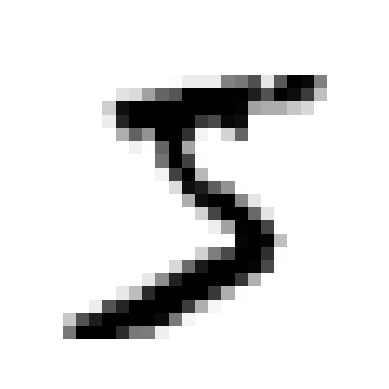

In [16]:
def display(img):
    img_re = img.reshape(28,28)
    plt.imshow(img_re, cmap = mpl.cm.binary, interpolation = "nearest") #used mpl's binary colormap instead of "gray". Colormap inverts intensity (0 → white, 1 → black)
    plt.axis("off")
    plt.show()
display(img)

In [17]:
label

5

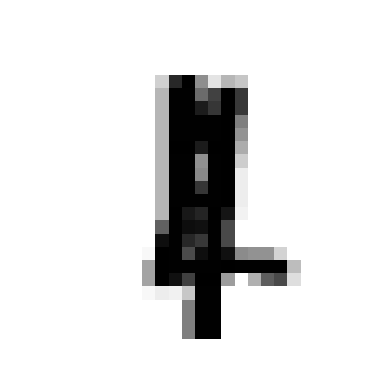

Label:  4


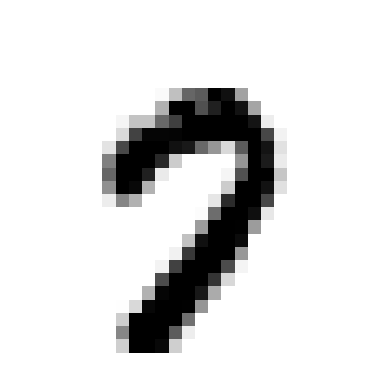

Label:  7


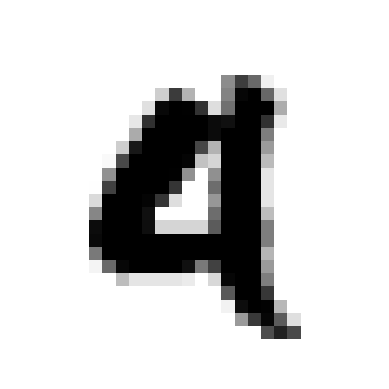

Label:  4


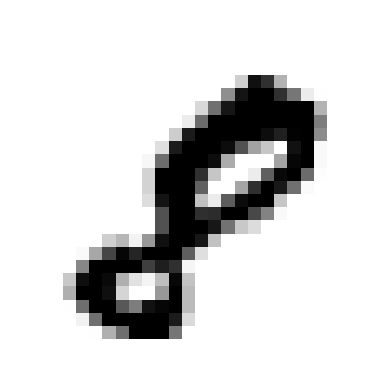

Label:  8


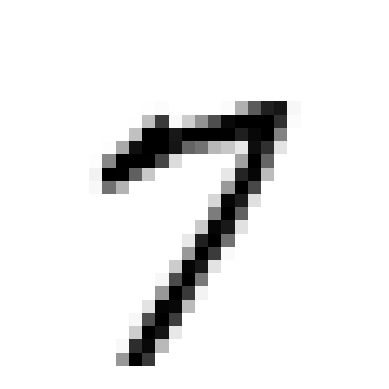

Label:  7


In [18]:
import random
for i in range(5):
    random.seed(i)
    img, label = train_ds[random.randint(0,60000)]
    display(img)
    print("Label: ",label)

Train/Validation/Test Split

In [19]:
import torch
from torch.utils.data import random_split

def split_train_val(dataset, train_size=50_000, val_size=10_000, seed=42):
    assert train_size + val_size == len(dataset)

    generator = torch.Generator().manual_seed(seed)
    train_set, val_set = random_split(
        dataset,
        [train_size, val_size],
        generator=generator
    )
    return train_set, val_set

In [20]:
train_set, val_set = split_train_val(train_ds)
test_set = test_ds

In [21]:
print("Train Set Size: ", len(train_set))
print("Validation Set Size: ", len(val_set))
print("Test Set Size: ", len(test_set))

Train Set Size:  50000
Validation Set Size:  10000
Test Set Size:  10000


Check digit distribution per split (class balance)
-If balance shifts badly: use a stratified split. In this case, it's fine

In [22]:
from collections import Counter
def counting_digit(dataset):
    labels = [label for _, label in dataset] #because dataset consists of images and labels
    return Counter(labels)
print("Elements distribution in Train Set: ", counting_digit(train_set))
print("Elements distribution in Validation Set: ", counting_digit(val_set))
print("Elements distribution in Test Set: ", counting_digit(test_set))

Elements distribution in Train Set:  Counter({1: 5613, 7: 5204, 3: 5093, 9: 4985, 2: 4958, 6: 4933, 0: 4923, 8: 4882, 4: 4863, 5: 4546})
Elements distribution in Validation Set:  Counter({1: 1129, 7: 1061, 3: 1038, 2: 1000, 0: 1000, 6: 985, 4: 979, 8: 969, 9: 964, 5: 875})
Elements distribution in Test Set:  Counter({1: 1135, 2: 1032, 7: 1028, 3: 1010, 9: 1009, 4: 982, 0: 980, 8: 974, 6: 958, 5: 892})


Normalization

In [23]:
from pprint import pprint
pprint({
    "type": type(img),
    "dtype": img.dtype,
    "shape": tuple(img.shape),
    "min": img.min().item(),
    "max": img.max().item(),
    "device": img.device,
    "contiguous": img.is_contiguous(),
})


{'contiguous': True,
 'device': device(type='cpu'),
 'dtype': torch.float32,
 'max': 0.9960784316062927,
 'min': 0.0,
 'shape': (1, 28, 28),
 'type': <class 'torch.Tensor'>}


Reshaping

In [24]:
from torch.utils.data import DataLoader
batch_size = 64
train_loader = DataLoader(
    train_set, batch_size = batch_size, shuffle=True
)

In [25]:
images, labels = next(iter(train_loader))

In [26]:
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


Random Samples Visualization

In [ ]:
#pick random samples from the batch
k = 12
# Create shuffled indices [0, ..., batch_size-1] and take the first k to sample images randomly
idx = torch.randperm(images.size(0))[:k] 

In [28]:
#plot in a grid
cols = 6
rows = (k + cols -1) //cols

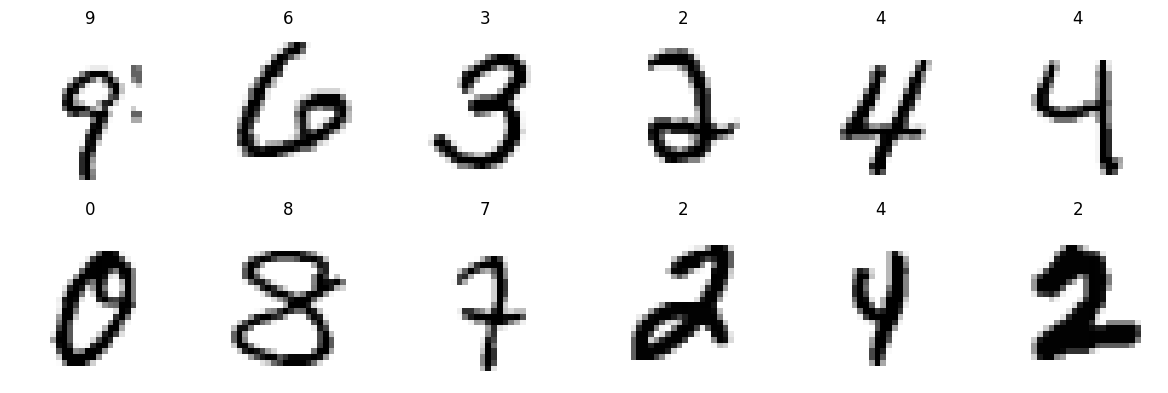

In [ ]:
plt.figure(figsize = (12,4))
for i, j in enumerate(idx): 
    #i: 0,1,2...(The position in your plot)
    #j: the actual random batch index(which image to pick)
    plt.subplot(rows,cols, i+1)
    img = images[j].squeeze(0) # Remove the channel dimension (1, 28, 28 → 28, 28) for visualization only
    plt.imshow(img,cmap=mpl.cm.binary)
    plt.title(int(labels[j]))
    plt.axis("off")
plt.tight_layout()
plt.show()

One Sample per Digit
“Some digits (e.g., 7 and 1) show visual overlap even in single-sample inspection, suggesting inherent class ambiguity.”

In [32]:
one_per_digit = {}
for idx in range(len(train_set)):
    img, label = train_set[idx]
    digit = int(label) if not torch.is_tensor(label) else int(label.item())
    if digit not in one_per_digit:
        one_per_digit[digit] = (img, idx) #idx is saved for handy debugging, to refer back to the original dataset, where it came from
    if len(one_per_digit) == 10:
        break
#safety check
missing = [d for d in range(10) if d not in one_per_digit]
assert len(missing)== 0, f"Missing digits: {missing}" #assert condition, error_message

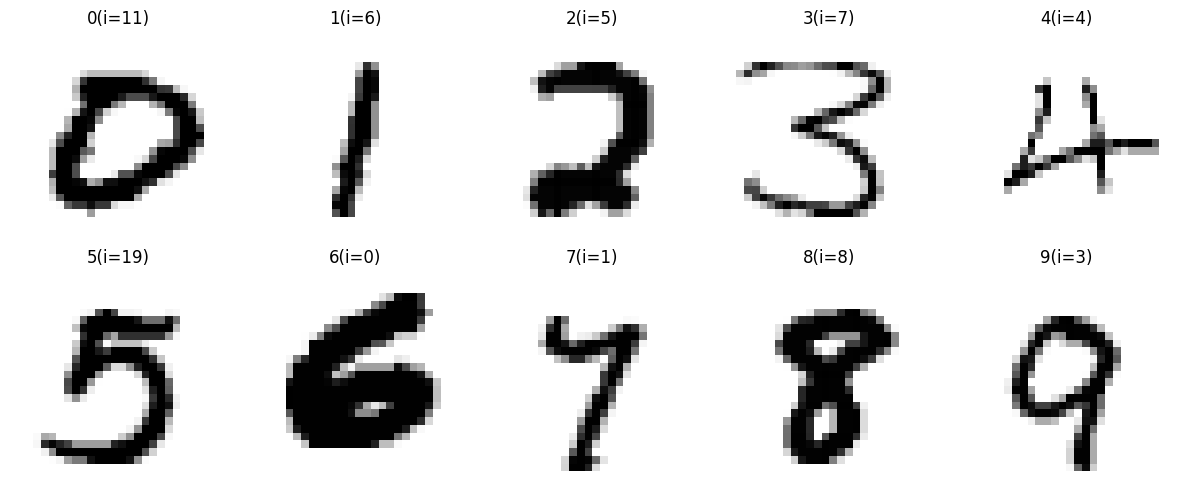

In [34]:
cols = 5
rows = 2
plt.figure(figsize=(12,5))
for d in range(10):
    img, idx = one_per_digit[d]
    plt.subplot(rows,cols,d+1)
    plt.imshow(img.squeeze(0),cmap = mpl.cm.binary)
    plt.title(f"{d}(i={idx})")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
#image 7 (i=1) looks slightly confusing. could be confused with number 1
# When you later see 1 ↔ 7 confusion, you’ll be able to say:

# “This isn’t just a model failure — it reflects intrinsic visual overlap observed during data inspection.”

Mean Image per Class

In [35]:
num_classes = 10
img_height, img_width = 28,28
# Accumulators
class_sums = torch.zeros(num_classes, img_height, img_width)
class_counts = torch.zeros(num_classes)

In [36]:
# Disable gradients
with torch.no_grad():
    for images, labels in train_loader:
        # images: [B, 1, 28, 28]
        images = images.squeeze(1)  # -> [B, 28, 28]

        for i in range(images.size(0)):
            label = labels[i].item()
            class_sums[label] += images[i]
            class_counts[label] += 1

In [37]:
class_means = class_sums / class_counts.view(-1, 1, 1)
class_means.shape

torch.Size([10, 28, 28])

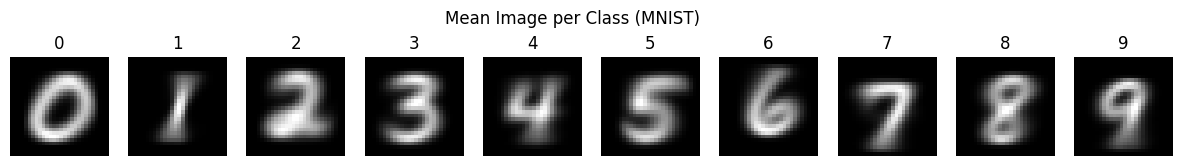

In [38]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for digit in range(10):
    axes[digit].imshow(class_means[digit], cmap='gray')
    axes[digit].set_title(str(digit))
    axes[digit].axis('off')

plt.suptitle("Mean Image per Class (MNIST)")
plt.show()

In [39]:
print(class_counts)
print(class_means.min().item(), class_means.max().item())

tensor([4923., 5613., 4958., 5093., 4863., 4546., 4933., 5204., 4882., 4985.])
0.0 0.9665653705596924


Pixel Intensity Histogram

Observations & Answers